In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [2]:
dataset=pd.read_csv('Mall_Customers.csv')
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
x=dataset.iloc[:,[3,4]].values


In [6]:
min_pts=2*x.shape[1]
min_pts

4

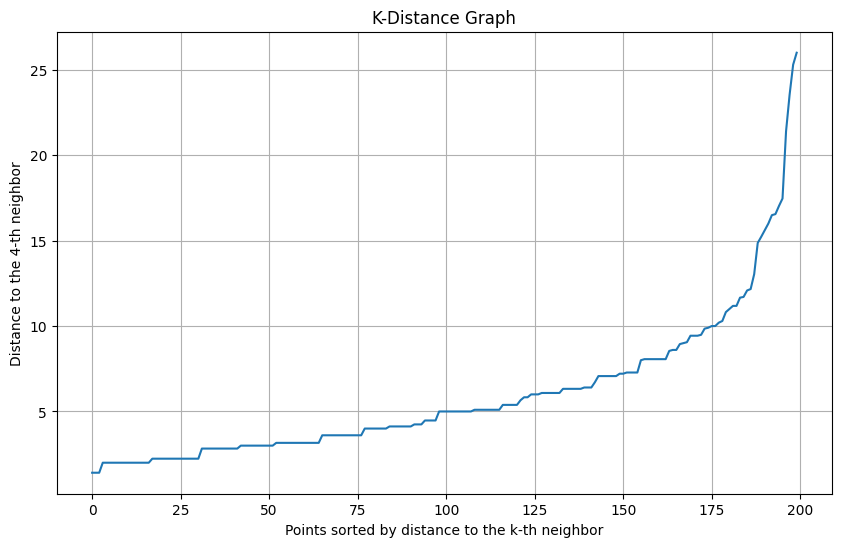

In [9]:
#To find eps
# The NearestNeighbors model finds the k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

# 4. Sort the distances and plot
# Sort distances to the k-th neighbor in ascending order
distances = np.sort(distances[:, (min_pts-1)], axis=0) # Get the distance to the k-th neighbor
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph')
plt.xlabel('Points sorted by distance to the k-th neighbor')
plt.ylabel(f'Distance to the {min_pts}-th neighbor')
plt.grid(True)
plt.show()

In [16]:
#We set epsilon=0.12 based on our k-distance graph
# Perform DBSCAN clustering
epsilon = 12  # Chosen based on k-distance graph
min_samples = 4  # 2 * dimensions (2D data)



In [27]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
y_pred = dbscan.fit_predict(x)
y_pred

# Noise points
#noise = (labels == -1)
#noise_points = x[noise]

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
        1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,
        0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,
       -1,  0,  1,  0, -1, -1,  1, -1, -1, -1, -1, -1, -1])

In [28]:
supervised=dataset
supervised['cluster_group']=y_pred
supervised

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster_group
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [29]:
supervised.to_csv('cluster_dbscan.csv',index=False)
supervised.columns[3:6]

Index(['Annual Income (k$)', 'Spending Score (1-100)', 'cluster_group'], dtype='object')

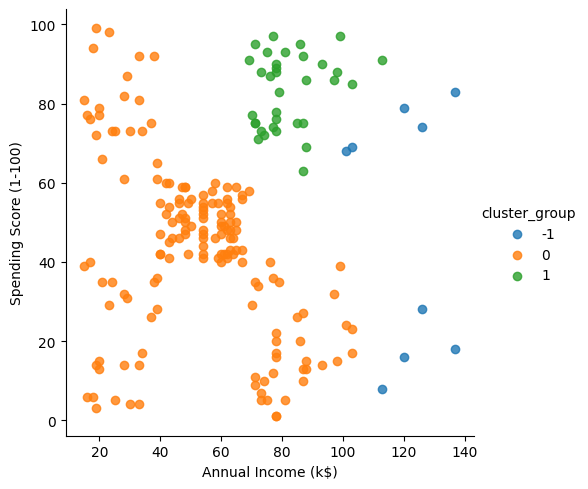

In [30]:
import seaborn as sns
facet = sns.lmplot(data=supervised, x=supervised.columns[3], y=supervised.columns[4], hue=supervised.columns[5], 
                   fit_reg=False, legend=True)

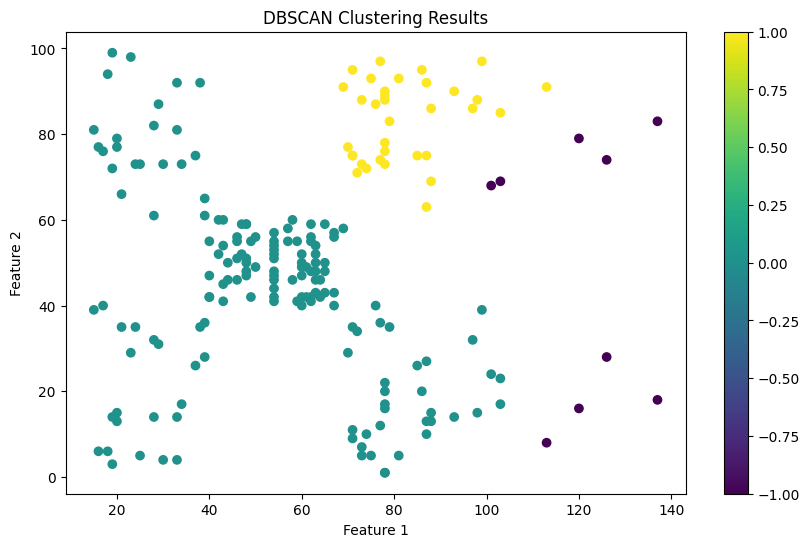

In [32]:
# Visualize the results
"""
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x[:, 0], x[:, 1], c=y_pred, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
"""
